<a href="https://colab.research.google.com/github/sakshijadhav-08/python-visualization-assignment/blob/main/17_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
filepath = "./heart.csv"
df = pd.read_csv(filepath)
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
df.shape

(918, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()
df.shape

(918, 12)

In [ ]:
ch_zero = (df["Cholesterol"] == 0).sum()
ch_zero

np.int64(172)

In [ ]:
bp_zero = (df["RestingBP"] == 0).sum()
bp_zero

np.int64(1)

In [ ]:
df[["Cholesterol", "RestingBP"]].describe()

,Cholesterol,RestingBP
count,918.000000,918.000000
mean,198.799564,132.396514
std,109.384145,18.514154
min,0.000000,0.000000
25%,173.250000,120.000000
50%,223.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


In [ ]:
ch_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0, ch_mean)
df["Cholesterol"] = df["Cholesterol"].round(2)
ch_mean

np.float64(244.6353887399464)

In [ ]:
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)
df["RestingBP"] = df["RestingBP"].round(2)
bp_mean

np.float64(132.54089422028352)

In [ ]:
print(df[["Cholesterol", "RestingBP"]].describe())

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


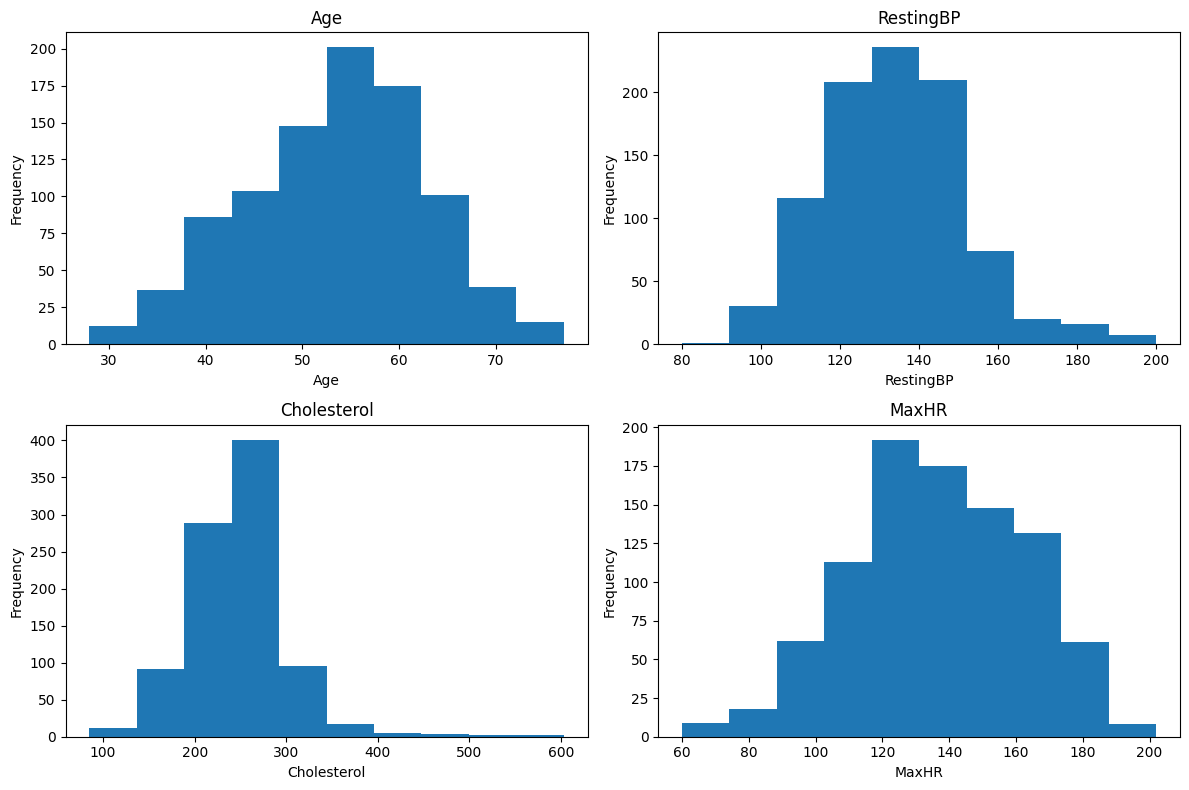

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(df["Age"])
plt.title("Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(2, 2, 2)
plt.hist(df["RestingBP"])
plt.title("RestingBP")
plt.xlabel("RestingBP")
plt.ylabel("Frequency")

plt.subplot(2, 2, 3)
plt.hist(df["Cholesterol"])
plt.title("Cholesterol")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(df["MaxHR"])
plt.title("MaxHR")
plt.xlabel("MaxHR")
plt.ylabel("Frequency")

plt.tight_layout()

In [ ]:
numerical_columns = df.select_dtypes(include=["int64","float64"]).columns
numerical_columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [ ]:
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [ ]:
df_encoded = pd.get_dummies(df)
df_encoded.shape

(918, 21)

In [ ]:
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [ ]:
df_encoded.shape

(918, 21)

In [ ]:
df_encoded.columns.tolist()

['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'HeartDisease',
 'Sex_F',
 'Sex_M',
 'ChestPainType_ASY',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_LVH',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_N',
 'ExerciseAngina_Y',
 'ST_Slope_Down',
 'ST_Slope_Flat',
 'ST_Slope_Up']

Summary:

I found some values in Cholesterol and RestingBP that were 0.
Since those values are not correct, I replaced them with the average value.

This is important because wrong values can affect the analysis and give incorrect results.

Then I used One-Hot Encoding to convert the categorical columns into numbers so the machine learning model can use them.

After cleaning and encoding, the dataset became better and ready for further analysis.
Bcz we cleared all 0 values from Cholesterol and RestingBP there will be no issue ahead.
And more cleaning like this was done.